In [1]:
# Hospital Readmission Prediction using Logistic Regression

**Goal:** Predict whether a diabetic patient will be readmitted to the hospital within 30 days using Logistic Regression with L2 regularization.

Hospital readmission prediction is a classification problem. The model learns from patient information such as diagnosis codes, hospital stay information, laboratory procedures, medications, and previous hospital visits.

We will evaluate the model mainly using **ROC-AUC** and discuss why false negatives and false positives have different clinical costs.

## Workflow

1. Download and load dataset
2. Explore the data
3. Prepare the target variable
4. Handle missing values
5. Select useful features
6. Separate features (X) and target (y)
7. Train/test split
8. Train Logistic Regression with L2 regularization
9. Predict readmission probability
10. Evaluate using ROC-AUC
11. Analyze false positives vs false negatives

SyntaxError: invalid syntax (3665100499.py, line 3)

In [ ]:
## Step 1 — Download and Load the Dataset

💡 **Why we do this:** Before a machine learning model can learn, it needs data. We use the Diabetes 130-US Hospitals dataset, which contains hospital encounter records of diabetic patients.

We use `kagglehub` to download the dataset directly from Kaggle and Pandas to load the CSV into a DataFrame.

🔧 **Function breakdown:**

- `kagglehub.dataset_download()` → downloads the dataset and returns its local path.
- `os.listdir()` → shows the files downloaded.
- `pd.read_csv()` → loads the CSV into a Pandas DataFrame.
- `df.head()` → displays the first five rows.

In [2]:
!pip install -q kagglehub

import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, precision_score, recall_score

path = kagglehub.dataset_download("brandao/diabetes")

print("Path to dataset files:", path)
print("Files:", os.listdir(path))

df = pd.read_csv(os.path.join(path, "diabetic_data.csv"))

df.head()

Using Colab cache for faster access to the 'diabetes' dataset.
Path to dataset files: /kaggle/input/diabetes
Files: ['description.pdf', 'diabetic_data.csv']


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
print("Shape:", df.shape)

display(df.head())

df.info()

display(df.describe(include="all").T)

print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

print("Readmission distribution:")
display(df["readmitted"].value_counts())

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983458,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,101766,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,101766,10,?,98569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


Missing values:


,0
max_glu_serum,96420
A1Cresult,84748
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


Readmission distribution:


,count
readmitted,
NO,54864
>30,35545
<30,11357


In [4]:
df = df.replace("?", np.nan)

df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

print("Target distribution:")
display(df["readmitted_30"].value_counts())

Target distribution:


,count
readmitted_30,
0,90409
1,11357


In [5]:
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

Missing values:


,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
patient_nbr,0


In [6]:
features = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "diag_1",
    "diag_2",
    "diag_3",
    "number_diagnoses",
    "max_glu_serum",
    "A1Cresult",
    "insulin",
    "change",
    "diabetesMed"
]

X = df[features]
y = df["readmitted_30"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (101766, 22)
y shape: (101766,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 81412
Testing samples: 20354


In [8]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'insulin', 'change', 'diabetesMed']
Numeric features: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


In [9]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=1000,
        solver="liblinear"
    ))
])

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [10]:
y_prob = model.predict_proba(X_test)[:, 1]

display(pd.DataFrame({
    "Actual": y_test.values,
    "Readmission Probability": y_prob
}).head(10))

,Actual,Readmission Probability
0,0,0.136338
1,0,0.059914
2,0,0.136925
3,1,0.240534
4,1,0.093503
5,0,0.031819
6,0,0.054619
7,0,0.068076
8,0,0.272385
9,0,0.193657


In [11]:
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.6441178943621994


In [12]:
threshold = 0.5

y_pred = (y_prob >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

print("\nPrecision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

True Negatives: 18036
False Positives: 47
False Negatives: 2227
True Positives: 44

Precision: 0.4835164835164835
Recall: 0.019374724790841038

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.48      0.02      0.04      2271

    accuracy                           0.89     20354
   macro avg       0.69      0.51      0.49     20354
weighted avg       0.84      0.89      0.84     20354



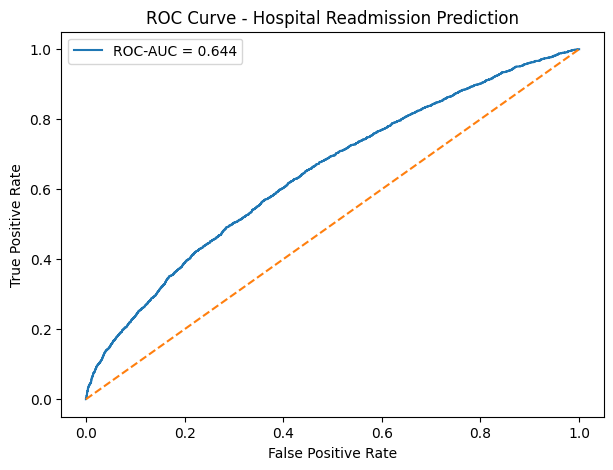

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")
plt.legend()
plt.show()

In [14]:
coefficients = model.named_steps["classifier"].coef_[0]

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute_Coefficient"] = coefficient_df["Coefficient"].abs()

coefficient_df = coefficient_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

display(coefficient_df.head(20))

,Feature,Coefficient,Absolute_Coefficient
239,categorical__diag_1_356,1.635828,1.635828
166,categorical__diag_1_271,1.563498,1.563498
1461,categorical__diag_3_156,1.501827,1.501827
717,categorical__diag_1_V58,1.463526,1.463526
1566,categorical__diag_3_273,1.401029,1.401029
468,categorical__diag_1_643,1.381037,1.381037
2185,categorical__diag_3_V60,1.344276,1.344276
163,categorical__diag_1_263,1.339453,1.339453
43,categorical__diag_1_146,1.321992,1.321992
732,categorical__diag_2_136,1.315451,1.315451
